# Proyecto de optimización y diagnostico de inventario
En este proyecto analizaremos el inventario de una tienda, encontrando los tres pilares claves:
- Productos que matan: Alto indice de devolución
- Productos muertos: Baja rotación
- Productos Hereos: Alta rotacion o Baja devolución o Buena ganacia Total
-
- **NOTA**: Estos datos nos ayudaran a generar un diagnostico del inventario en base a su rotación y rentabilidad

In [3]:
# importamos pandas y numpy para que nos ayude con el analisis
import pandas as pd
import numpy as np
# FIJAMOS la semilla para que los datos no se muevan con cada "run"
np.random.seed(42)

In [4]:
#cantidad de productos para la test table 
n_productos=1000
#generamos id 
ids=[f'PROD-{str(i).zfill(3)}' for i in range(1, n_productos + 1)]
#categoria de tienda 
categoria=['AUIDIO','CABLES','ENERGIA','GADGETS','ACCESORIOS','GAMER']
#selección de categoria 
seleccion_cat= np.random.choice(categoria,size=n_productos)

In [5]:
#CREAMOS PRECIOS 
base_aleatoria= np.random.beta(a=0.5,b=40,size=n_productos)
precios_raw=base_aleatoria*30000
precios_venta= np.where(precios_raw < 99,
                       np.where(np.random.rand(n_productos)<0.2,49,
                       np.random.uniform(99,399,size=n_productos)), precios_raw)
precios_venta= np.round(precios_venta,0)
#REGLAS DEL JUEGO 
indices_disponibles=np.where(precios_venta <= 399)[0]
tamaño_bajo=int(n_productos * .02)
tamaño_premium= int(n_productos*0.10)
indices_49=np.random.choice(indices_disponibles,size=tamaño_bajo, replace=False)
precios_venta[indices_49]=49
indices_mas_caros=np.argsort(precios_venta)[-tamaño_premium:]
precios_venta[indices_mas_caros]=np.round(np.random.uniform(14000,20000,size=tamaño_premium),0)

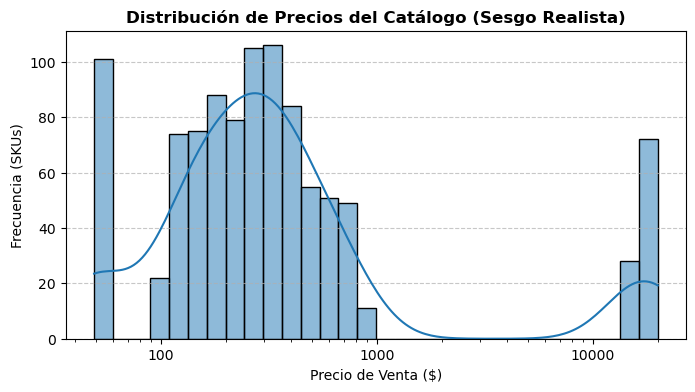

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

plt.figure(figsize=(8, 4))

# Reactivamos kde=True para la línea suave
ax = sns.histplot(precios_venta, log_scale=(True, False), kde=True, color='#1f77b4', bins=30)

# Formateamos el eje X para quitar las potencias (10^2, 10^3) y ver números normales
ax.xaxis.set_major_formatter(ScalarFormatter())

plt.title('Distribución de Precios del Catálogo (Sesgo Realista)', fontsize=12, fontweight='bold')
plt.xlabel('Precio de Venta ($)')
plt.ylabel('Frecuencia (SKUs)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [7]:
#Creamos los margenes 
margen=[]
#Filtramos precios para brindar margenes faciles y con un loop for vamos llenando la biblioteca de margenes
for i in precios_venta:
    if i < 300:
        margen_base=0.5
    elif i <= 2000:
        margen_base=0.20
    else:
        margen_base=0.1
    ruido= np.random.uniform(-0.03,0.03)
    margen_final= margen_base+ruido
    margen.append(np.round(margen_final,2))

In [8]:
#Creamos un numero de productos que sea menor volumen conforme a mayor precio
#pero que esto sea impredecible y organico, para darle ese toque vivo 
#Creamos una diccionario donde ser guardado
num_per_product= []
for i in precios_venta:
    #1.Base porporcional inversa 
    venta_base= 10000/(i+50)
    #2.Caos inyectado
    caos= np.random.uniform(0.1,5)
    #3.Random producto muerto
    if np.random.rand()<.20:
        unidades_finales=np.random.choice([0,10])
    else: 
        unidades_finales=int(venta_base*caos)
    num_per_product.append(unidades_finales)

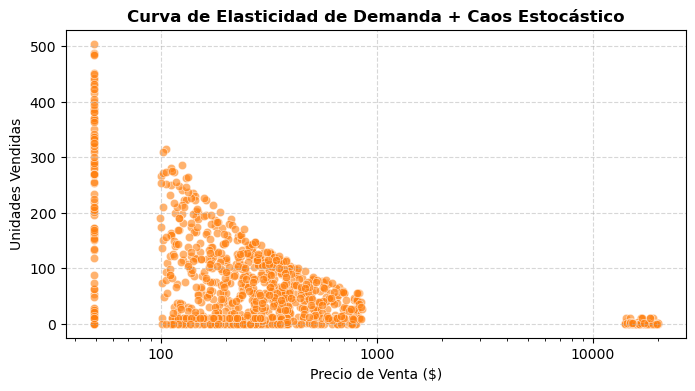

In [25]:
plt.figure(figsize=(8, 4))
ax = sns.scatterplot(x=precios_venta, y=num_per_product, alpha=0.6, color='#ff7f0e')

# Aplicamos la escala logarítmica en el eje X
plt.xscale('log')

# Formateamos el eje X para quitar notación científica/potencias
ax.xaxis.set_major_formatter(ScalarFormatter())

plt.title('Curva de Elasticidad de Demanda + Caos Estocástico', fontsize=12, fontweight='bold')
plt.xlabel('Precio de Venta ($)')
plt.ylabel('Unidades Vendidas')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [10]:
#Creamos los datos, nota: utilizaremos funciones de numpy para reducir espacio y se vea mejor
#base sana
tasa_sana= np.random.uniform(1.5,0.25,size=n_productos)
#picos defectuosos
tasa_defecto=np.random.uniform(4.0,15.0,size=n_productos)
#logica
tasa_devolucion= np.where((precios_venta<1500)&(np.random.rand(n_productos)<0.15)
                          ,tasa_sana + tasa_defecto,
                         np.random.uniform(0.2,1.5,size=n_productos))
#tasa de devolución ya redondeada
tasa_devolucion= np.round(tasa_devolucion,2)

In [11]:
# 1. Base estándar para productos económicos (de 3 a 20 días)
base_dias = np.random.uniform(3, 30, size=n_productos)

# 2. Regla General Premium: Si es caro (> 2000), pasa entre 25 y 90 días en bodega
dias_bodega = np.where(precios_venta > 2000, 
                       np.random.uniform(25, 90, size=n_productos), 
                       base_dias)

# 3. EXCEPCIÓN DE NEGOCIO (Tu evento raro): 
# Buscamos cuáles productos son caros Y ADEMÁS tienen la suerte de venderse rápido (20% de probabilidad)
indices_caros = np.where(precios_venta > 2000)[0]
if len(indices_caros) >= 0:
    # De los productos caros, elegimos al azar un 20% de ellos para que sean "bestsellers"
    cantidad_bestsellers = int(np.ceil(len(indices_caros) * 0.9))
    indices_bestsellers = np.random.choice(indices_caros, size=cantidad_bestsellers, replace=False)
    
    # A esos cuantos afortunados les asignamos una rotación súper rápida (de 1 a 15 días)
    dias_bodega[indices_bestsellers] = np.random.uniform(0, 15, size=cantidad_bestsellers)

# 4. Castigo por alta devolución (Suma entre 5 y 15 días si la tasa > 5.0)
dias_bodega = np.where(tasa_devolucion > 5.0, 
                       dias_bodega + np.random.uniform(5, 15, size=n_productos), 
                       dias_bodega)

# 5. Redondeamos a enteros
dias_bodega = np.round(dias_bodega, 0).astype(int)

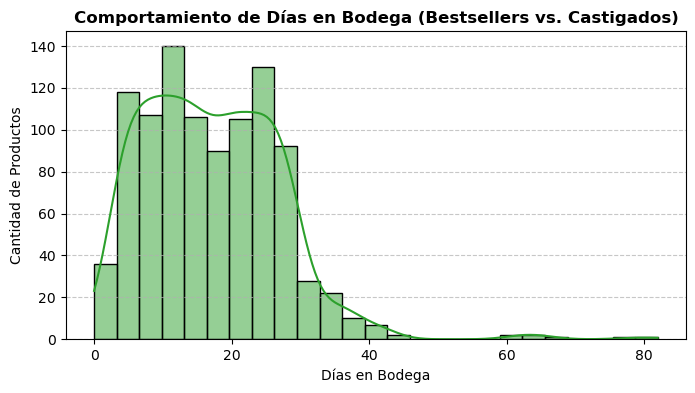

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(dias_bodega, kde=True, color='#2ca02c', bins=25)
plt.title('Comportamiento de Días en Bodega (Bestsellers vs. Castigados)', fontsize=12, fontweight='bold')
plt.xlabel('Días en Bodega')
plt.ylabel('Cantidad de Productos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [13]:
#PONER CARA AL FANTASMA
#creamos las clases
class generador:
    def __init__(self,configuracion_biomas):
        self.config= configuracion_biomas
    def _calcu_afi(self,precio,rango):
        min_p, opt_p, max_p= rango
        if not(min_p <= precio <= max_p):
            return 0.005 #ruido base
        if precio <= opt_p:
            return 2*(precio - min_p)/ (max_p - min_p) * (opt_p - min_p) + 1e-5
        else:
            return 2*(max_p - precio)/ (max_p * min_p) * (max_p - opt_p) +1e-5
    def _gen_arti(self,categoria,precio):
        bioma= self.config.get(categoria)
        if not bioma:
            return "GENÉRICO", f"Accesorio {categoria.capitalize()}"
        marcas= list(bioma['marcas'].keys())
        afinidades= [self._calcu_afi(precio,bioma['marcas'][m]) for m in marcas]
        probabilidades = np.array(afinidades) / sum(afinidades)
        marca_selecionada= np.random.choice(marcas, p=probabilidades)
        
        #GENERACIÓN SEMANTICA mayo a menor
        nombre_base= "Accesorios General"
        for escalon_precio, descriptor in sorted(bioma['nombres'].items(), reverse= True):
            if precio >= escalon_precio:
                nombre_base= descriptor
                break
        return marca_selecionada, f"{nombre_base}"
#CONFIGURACIÓN CALIBRADA 
#MIN 49 MAX 20,000
CONFIGURACION_CUMBRES={
    'AUDIO': {
        'marcas': {
            'SONY': [200, 4000, 20000], 'JBL': [300, 3000, 18000], 'LOGITECH': [150, 1500, 10000],
            'AIWA': [200, 1000, 6000], 'ONE HOUR': [40, 200, 1500], 'CYBERSHOP': [40, 150, 1000],
            'STF': [80, 300, 2000], 'SELECT': [40, 120, 800]
        },
        'nombres': {
            0: "Audífonos In-Ear Básicos",
            600: "Bocina Bluetooth Portátil",
            5000: "Sistema de Audio / Diadema Premium ANC"
        }
    },
    'CABLES': {
        'marcas': {
            'APPLE': [300, 800, 19000], 'UGREEN': [100, 500, 12000], 'BASEUS': [100, 400, 10000],
            'MITZU': [30, 100, 2000], 'ONE HOUR': [30, 80, 1500], 'CYBERSHOP': [30, 70, 1000],
            'GMOBILE': [30, 60, 800]
        },
        'nombres': {
            0: "Cable de Carga Estándar",
            300: "Cable Uso Rudo Alta Velocidad",
            4000: "Hub Docking Station Multiportas Premium"
        }
    },
    'GADGETS': {
        'marcas': {
            'APPLE': [800, 8000, 20000], 'SAMSUNG': [600, 6000, 20000], 'DJI': [1200, 10000, 20000],
            'STARLINK': [1000, 7000, 20000], 'AMAZON': [400, 1500, 5000], 'LENOVO': [500, 2500, 12000],
            'DEBUGG': [150, 500, 3000]
        },
        'nombres': {
            0: "Accesorio / Smart Tag",
            1000: "Asistente Virtual Inteligente",
            6000: "Dispositivo Tecnológico High-End"
        }
    },
    'ENERGIA': {
        'marcas': {
            'PERFECT CHOICE': [150, 1200, 20000], 'RADIOSHORK': [100, 1000, 15000],
            'ONE HOUR': [40, 200, 3000], 'CYBERSHOP': [40, 150, 2000]
        },
        'nombres': {
            0: "Power Bank Carga Rápida",
            1500: "Regulador de Voltaje de Alta Capacidad",
            8000: "Sistema No-Break Industrial"
        }
    },
    'ACCESORIOS': {
        'marcas': {
            'PERFECT CHOICE': [100, 800, 18000], 'KOBLENZ': [200, 1500, 15000], 
            'RICHARDS': [100, 600, 10000], 'DEBUGG': [50, 300, 4000], 'ONE HOUR': [40, 150, 2000]
        },
        'nombres': {
            0: "Mouse Óptico de Oficina",
            800: "Teclado Inalámbrico Ergonómico",
            4000: "Kit de Accesorios Ejecutivos"
        }
    },
    'GAMER': {
        'marcas': {
            'LOGITECH G': [200, 2500, 20000], 'RAZER': [300, 3000, 20000],
            'RED DRAGON': [150, 1000, 8000], 'WESTMISTER': [100, 600, 5000]
        },
        'nombres': {
            0: "Mouse Gamer con Pesas",
            1500: "Teclado Mecánico RGB Pro",
            6000: "Silla Gamer Ergonómica Pro"
        }
    }
}
#EJECUCIÓN
motor= generador(CONFIGURACION_CUMBRES)

resultado= [motor._gen_arti(cat,precio) for cat,precio in zip(seleccion_cat, precios_venta)]
lista_marcas,lista_nombres= zip(*resultado)

In [14]:
print("IDs:", len(ids))
print("Categorías:", len(seleccion_cat))
print("Precios:", len(precios_venta))
print("Márgenes:", len(margen))
print("Ventas:", len(num_per_product))
print("Devoluciones:", len(tasa_devolucion))
print("dias_bodega:", len(dias_bodega))
print('lista_marcas:',len(lista_marcas))
print('lista_nombres:',len(lista_nombres))

IDs: 1000
Categorías: 1000
Precios: 1000
Márgenes: 1000
Ventas: 1000
Devoluciones: 1000
dias_bodega: 1000
lista_marcas: 1000
lista_nombres: 1000


In [15]:
#Juntamos los data test y creamos la table test
table_taste= {
    'id_productos':ids,
    'categoria':seleccion_cat,
    'precio_venta':precios_venta,
    'margen': margen,
    'numero_productos': num_per_product,
    'tasa_devolucion': tasa_devolucion,
    'dias_bodega': dias_bodega,
    'lista_marcas': lista_marcas,
    'lista_nombres': lista_nombres
}
df_inventario= pd.DataFrame(table_taste)
pd.set_option('display.max_rows',None)
df_ordenado= df_inventario.sort_values(by='precio_venta', ascending=False)
df_ordenado

,id_productos,categoria,precio_venta,margen,numero_productos,tasa_devolucion,dias_bodega,lista_marcas,lista_nombres
84,PROD-085,GAMER,19944.0,0.08,0,0.39,8,LOGITECH G,Silla Gamer Ergonómica Pro
872,PROD-873,GADGETS,19938.0,0.11,1,1.28,12,DJI,Dispositivo Tecnológico High-End
498,PROD-499,ACCESORIOS,19895.0,0.10,1,1.32,10,DEBUGG,Kit de Accesorios Ejecutivos
966,PROD-967,GAMER,19768.0,0.09,0,0.41,11,LOGITECH G,Silla Gamer Ergonómica Pro
245,PROD-246,ENERGIA,19728.0,0.09,1,0.32,11,PERFECT CHOICE,Sistema No-Break Industrial
359,PROD-360,GADGETS,19719.0,0.09,0,1.21,42,DJI,Dispositivo Tecnológico High-End
579,PROD-580,GADGETS,19617.0,0.13,0,0.71,4,DJI,Dispositivo Tecnológico High-End
248,PROD-249,ENERGIA,19604.0,0.12,0,0.65,8,PERFECT CHOICE,Sistema No-Break Industrial
952,PROD-953,ACCESORIOS,19596.0,0.08,0,0.30,1,PERFECT CHOICE,Kit de Accesorios Ejecutivos
719,PROD-720,AUIDIO,19577.0,0.13,0,0.82,15,GENÉRICO,Accesorio Auidio


In [16]:
from pathlib import Path
#Casa
ruta_usuario = Path.home()
#le sumamos
ruta_descargas = ruta_usuario / "Downloads" / "inventario_cumbres.csv"
#Guardamos
df_ordenado.to_csv(ruta_descargas, index=False, encoding='utf-8-sig')

print(f"¡Hecho! El archivo se guardó en: {ruta_descargas}")

¡Hecho! El archivo se guardó en: C:\Users\Diego\Downloads\inventario_cumbres.csv
